In [ ]:
import sys
from pathlib import Path
repo_root = Path('/bg/home/janner-s/prob_cGAN_for_GEO_QPE')
sys.path.insert(0, str(repo_root / 'src'))
import prob_cGAN as pcgan
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from torch.utils.data import DataLoader

# Set up variables
model_path = repo_root / 'model' / 'generator.pth'
config = pcgan.load_config(str(repo_root / 'model' / 'config.yaml'))
selected_channels = config['data']['selected_channels']
n_lat,n_lon = 164,280
prev_time = config['data']['prev_time']
a = config['data']['a']

In [20]:
# Load data
ds_input_target = xr.open_zarr('/bg/data/mergosat/data/input_target_AMJ2019.zarr/')
input = ds_input_target['seviri input'].values
target= ds_input_target['radklim-yw'].values
target_agg = ds_input_target['radklim-yw hr agg'].values
lon = ds_input_target['LON'].values
lat = ds_input_target['LAT'].values
time = ds_input_target['time'].values

target_norm = pcgan.norm_precip(target,a)

# Predict with cGAN
ds = pcgan.Custom_Dataset(x=input, y=target_norm)
data_loader = DataLoader(dataset=ds, batch_size=100, shuffle=False)
generator =  pcgan.Unet_ensemble_3D_alldropout(T_in=config.model.in_time,in_channels=config.model.in_channels,in_features_G=config.model.in_features_G,dropout_cfg=config.dropout).cpu()
predictions=np.empty((1,len(target_norm),n_lat,n_lon))
for i in tqdm(range(1)):
    predictions_norm,_,_ = pcgan.calc_prediction(generator,model_path,data_loader,seed=1+i)
    predictions[i] = pcgan.reverse_norm_precip(predictions_norm,a).squeeze()


/bg/fast/env_janner-s/mambaforge/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
  0%|                                                     | 0/1 [00:00<?, ?it/s]/bg/home/janner-s/prob_cGAN_for_GEO_QPE/src/prob_cGAN.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loade

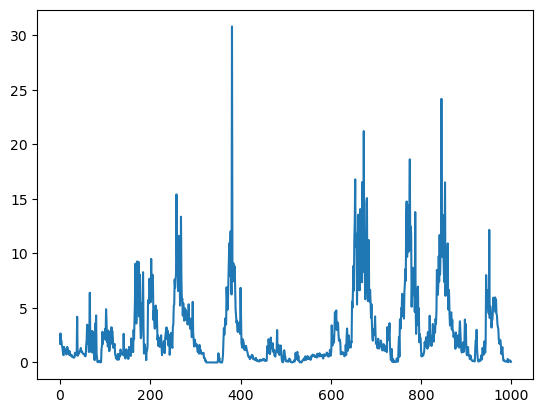

In [23]:
plt.plot(np.nanmax(target, axis=(1,2))[6000:7000], label='RADKLIM-YW max')

/bg/fast/env_janner-s/mambaforge/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/bg/fast/env_janner-s/mambaforge/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/bg/fast/env_janner-s/mambaforge/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/bg/fast/env_janner-s/mambaforge/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


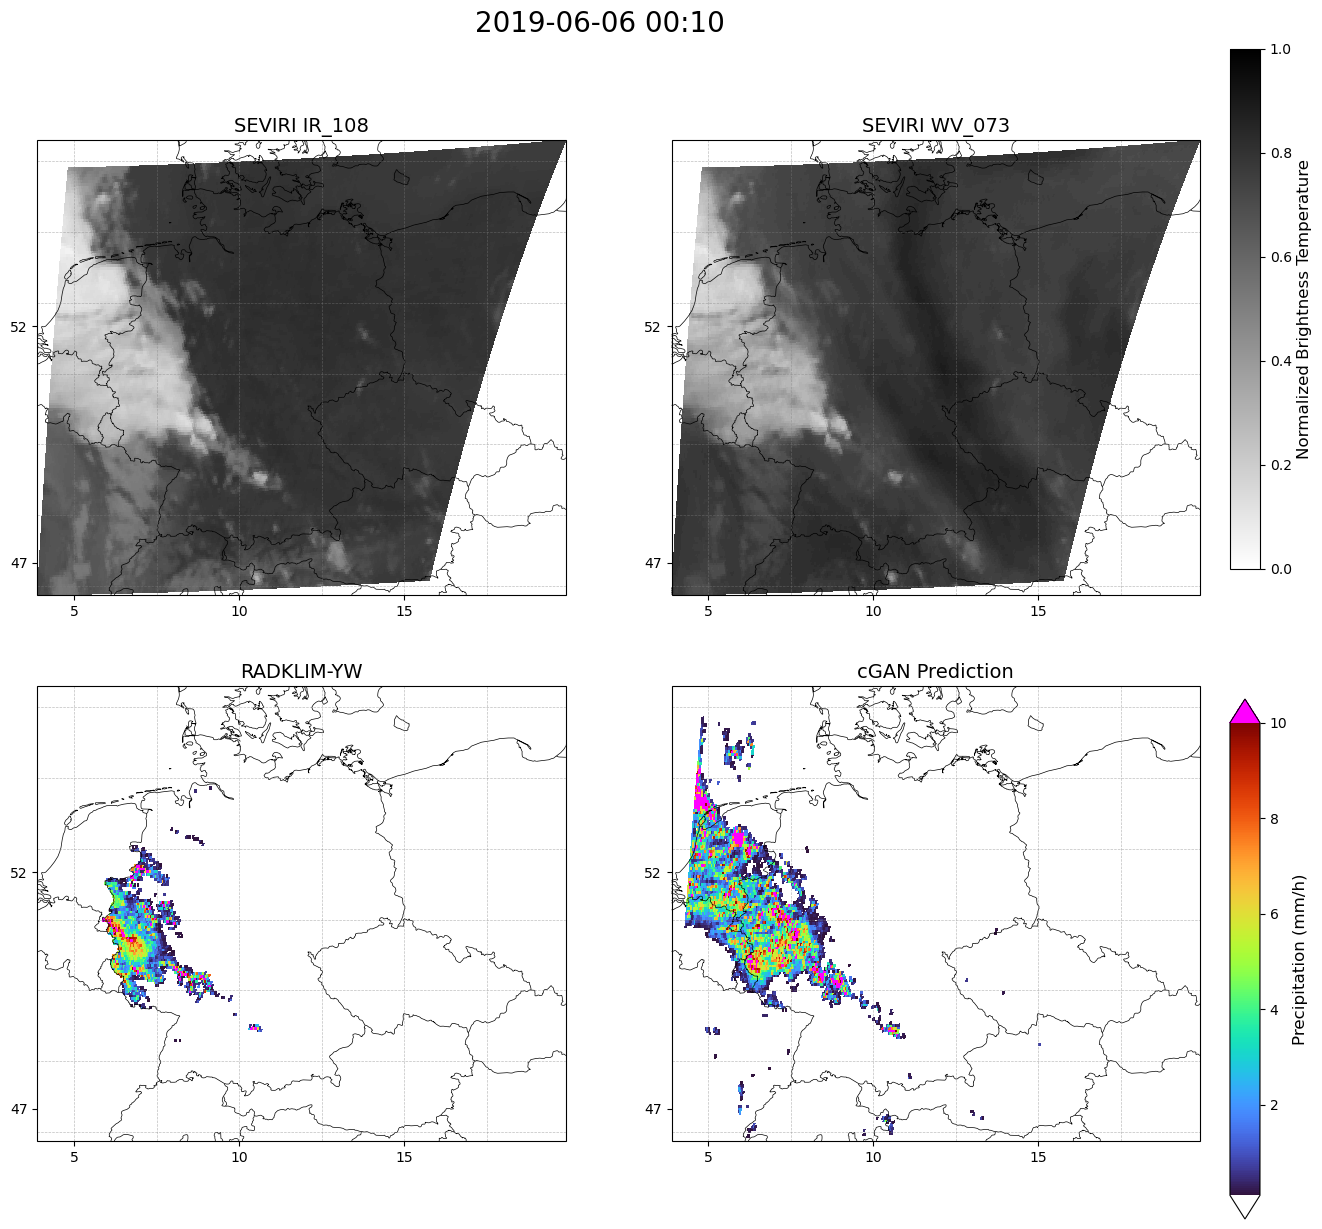

In [29]:
turbo_custom = plt.get_cmap('turbo')
# To set the under color to empty (no color), use 'none'
turbo_custom.set_under('none')
turbo_custom.set_over('magenta')
turbo_custom.set_bad('lightgray', alpha=0.3)

proj = ccrs.PlateCarree()


fig, ax = plt.subplots(2,2, figsize=(15,13), subplot_kw={'projection': proj})
# Reverse formula for index_example_hrly
index_example = 6210

p1=ax[0,0].pcolor(lon,lat,input[index_example,0,0], cmap='gray_r',vmin=0, vmax=1)
ax[0,0].set_title(f'SEVIRI {selected_channels[1]}')
ax[0,0].title.set_fontsize(14)
ax[0,1].set_title(f'SEVIRI {selected_channels[2]}')
ax[0,1].title.set_fontsize(14)
ax[0,1].pcolor(lon,lat,input[index_example,1,0], cmap='gray_r',vmin=0, vmax=1)

ax[1,0].set_title('RADKLIM-YW')
ax[1,0].title.set_fontsize(14)
p2=ax[1,0].pcolor(lon,lat,target[index_example]*12, cmap=turbo_custom, vmin=0.1, vmax=10)

ax[1,1].set_title('cGAN Prediction')
ax[1,1].title.set_fontsize(14)
ax[1,1].pcolor(lon,lat,predictions[0,index_example]*12, cmap=turbo_custom, vmin=0.1, vmax=10)


# iterate over axes to add features
# bundesländer borders
bundeslaender = cfeature.NaturalEarthFeature(category='cultural',
                                            name='admin_1_states_provinces_lines',
                                            scale='50m', facecolor='none')
for i in range(2):
    for j in range(2):
        ax[i,j].add_feature(cfeature.BORDERS,color='k', linewidth=0.5)
        ax[i,j].add_feature(cfeature.COASTLINE,color='k', linewidth=0.5)
        ax[i,j].add_feature(bundeslaender, linewidth=0.3, edgecolor='k')

        ax[i,j].set_aspect('auto')

        ax[i,j].set_xticks(np.arange(5,20,5))
        ax[i,j].set_yticks(np.arange(47,55,5))
        ax[i,j].set_xticklabels(np.arange(5,20,5))
        ax[i,j].set_yticklabels(np.arange(47,55,5))

        gridlines = ax[i,j].gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

plt.suptitle(
    f"{time[index_example].astype(str).replace('T', ' ')[:16]}",
    fontsize=20
)

# Add colorbar for the precipitation plots
cbar_ax = fig.add_axes([0.92, 0.05, 0.02, 0.4])  # [left, bottom, width, height]
cbar = fig.colorbar(p2, cax=cbar_ax,extend='both')
cbar.set_label('Precipitation (mm/h)', fontsize=12)
cbar.ax.tick_params(labelsize=10)
# add colorbar for the SEVIRI plots
cbar_ax2 = fig.add_axes([0.92, 0.55, 0.02, 0.4])  #[left, bottom, width, height]
cbar2 = fig.colorbar(p1, cax=cbar_ax2)
cbar2.set_label('Normalized Brightness Temperature', fontsize=12)
cbar2.ax.tick_params(labelsize=10)